# RandomWalks

In [1]:
import networkx as nx

In [2]:
G = nx.karate_club_graph()

In [3]:
print('Number of nodes:', len(G.nodes))

Number of nodes: 34


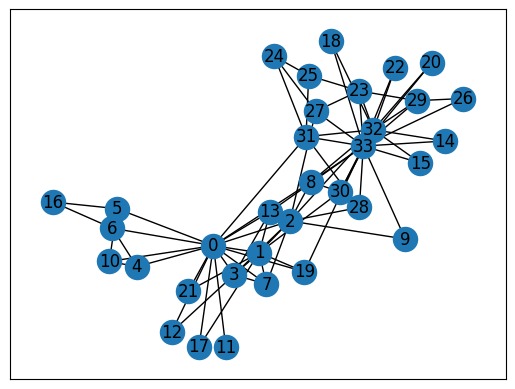

In [4]:
nx.draw_networkx(G)

Plot the graphs with labels

In [5]:
labels = []
for i in G.nodes:
    club_names = G.nodes[i]['club']
    labels.append(1 if club_names == 'Mr. Hi' else 0) #There are two clubs in the graph, 'Mr. Hi' and 'Officer'. We will use 1 to represent 'Mr. Hi' and 0 to represent 'Officer'.

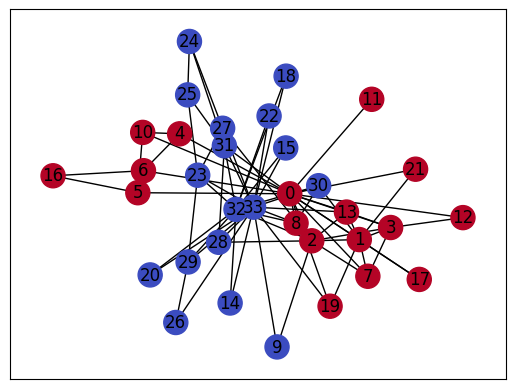

In [6]:
layout_pos = nx.spring_layout(G) #The spring layout is a force-directed layout algorithm that positions nodes in a way that minimizes edge crossings and distributes nodes evenly in the space. It simulates a physical system where nodes repel each other and edges act like springs, pulling connected nodes together. This results in a visually appealing layout that can help reveal the structure of the graph.
nx.draw_networkx(G, pos=layout_pos, node_color=labels, cmap='coolwarm')

**Perform node embeddings using DeepWalk**

In [7]:
from karateclub import DeepWalk

ModuleNotFoundError: No module named 'karateclub'

## USE PyGeomtric for DeepWalk (Karate club is older)

In [2]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.11.0+cpu
2.7.0


In [5]:
%pip install gensim

  Using cached gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   --- ------------------------------------ 1.8/24.4 MB 7.7 MB/s eta 0:00:03
   ------ --------------------------------- 3.7/24.4 MB 8.1 MB/s eta 0:00:03
   --------- ------------------------------ 5.8/24.4 MB 8.6 MB/s eta 0:00:03
   ------------ --------------------------- 7.6/24.4 MB 8.9 MB/s eta 0:00:02
   --------------- ------------------------ 9.7/24.4 MB 9.0 MB/s eta 0:00:02
   ------------------ --------------------- 11.5/24.4 MB 9.0 MB/s eta 0:00:02
   ---------------------- ----------------- 13.6/24.4 MB 9.1 MB/s eta 0:00:02
   ------------------------ --------------- 15.2/24.4 MB 9.1 MB/s eta 0:00:02
   -------------------------- ------------- 16.3/24.4 MB 8.7 MB/s eta 0:00:01
   ------------------------------ --------- 18.4/24.4 MB 8.5 MB/s eta 0:00:01
   ----------

In [6]:
"""
=========================================================
DeepWalk from Scratch using PyTorch Geometric
=========================================================

Pipeline:

1. Create Graph using PyTorch Geometric
2. Convert edge_index -> Adjacency List
3. Perform Random Walks
4. Treat walks as sentences
5. Train Word2Vec (Skip-Gram)
6. Obtain Node Embeddings

Author: Learning Version
"""

# ======================================================
# STEP 1 : Import Libraries
# ======================================================

import random
from collections import defaultdict

import torch
from torch_geometric.data import Data

from gensim.models import Word2Vec


# ======================================================
# STEP 2 : Create a Graph
# ======================================================
#
# Graph Structure:
#
#         0
#        / \
#       /   \
#      1-----2
#       \
#        \
#         3
#
# Undirected Edges:
#
# 0-1
# 0-2
# 1-2
# 1-3
#
# PyTorch Geometric stores edges as directed,
# therefore every undirected edge is stored twice.
# ======================================================

edge_index = torch.tensor([
    [0, 1, 0, 2, 1, 2, 1, 3],   # Source nodes
    [1, 0, 2, 0, 2, 1, 3, 1]    # Destination nodes
], dtype=torch.long)

# Create graph object
data = Data(edge_index=edge_index)

print("="*60)
print("Graph Information")
print("="*60)
print(data)
print("Number of Nodes :", data.num_nodes)
print("Number of Edges :", data.num_edges)


# ======================================================
# STEP 3 : Convert edge_index into Adjacency List
# ======================================================
#
# edge_index is not convenient for random walks.
#
# Convert:
#
# tensor([[0,1,0,2,...],
#         [1,0,2,0,...]])
#
# Into:
#
# {
#   0:[1,2],
#   1:[0,2,3],
#   2:[0,1],
#   3:[1]
# }
# ======================================================

adjacency = defaultdict(list)

# edge_index has two rows:
#
# Row 0 -> source
# Row 1 -> destination
#
sources = data.edge_index[0]
destinations = data.edge_index[1]

for src, dst in zip(sources.tolist(), destinations.tolist()):
    adjacency[src].append(dst)

print("\n")
print("="*60)
print("Adjacency List")
print("="*60)

for node in adjacency:
    print(f"Node {node} --> {adjacency[node]}")


# ======================================================
# STEP 4 : Define Random Walk Function
# ======================================================
#
# Example:
#
# Start = 0
#
# Possible Walk:
#
# 0 → 2 → 1 → 3 → 1 → 0
#
# ======================================================

def random_walk(adjacency, start_node, walk_length):

    # Store the path
    walk = [start_node]

    current_node = start_node

    # We already have first node,
    # so generate remaining nodes.
    for _ in range(walk_length - 1):

        neighbors = adjacency[current_node]

        # Stop if isolated node
        if len(neighbors) == 0:
            break

        # Randomly choose one neighbor
        next_node = random.choice(neighbors)

        # Add to walk
        walk.append(next_node)

        # Move to next node
        current_node = next_node

    return walk


# ======================================================
# STEP 5 : Test Single Random Walk
# ======================================================

print("\n")
print("="*60)
print("Single Random Walk")
print("="*60)

walk = random_walk(
    adjacency=adjacency,
    start_node=0,
    walk_length=6
)

print("Walk :", walk)


# ======================================================
# STEP 6 : Generate Many Random Walks
# ======================================================
#
# DeepWalk generates multiple walks
# from every node.
#
# ======================================================

num_walks = 5       # Walks per node
walk_length = 6

walks = []

for node in range(data.num_nodes):

    for _ in range(num_walks):

        walk = random_walk(
            adjacency,
            start_node=node,
            walk_length=walk_length
        )

        walks.append(walk)


print("\n")
print("="*60)
print("Generated Walks")
print("="*60)

for walk in walks:
    print(walk)


# ======================================================
# STEP 7 : Convert Walks into Sentences
# ======================================================
#
# Word2Vec expects words.
#
# Convert:
#
# [0,2,1,3]
#
# Into:
#
# ['0','2','1','3']
#
# ======================================================

sentences = []

for walk in walks:

    sentence = []

    for node in walk:
        sentence.append(str(node))

    sentences.append(sentence)

print("\n")
print("="*60)
print("Sentences for Word2Vec")
print("="*60)

for sentence in sentences[:5]:
    print(sentence)


# ======================================================
# STEP 8 : Train Word2Vec
# ======================================================
#
# Skip-Gram (sg=1)
#
# DeepWalk uses Skip-Gram.
#
# ======================================================

model = Word2Vec(
    sentences=sentences,

    # Dimension of embedding
    vector_size=16,

    # Context window
    window=2,

    # Use every node
    min_count=0,

    # Skip-Gram
    sg=1,

    # Training epochs
    epochs=100,

    # Single CPU
    workers=1
)

print("\n")
print("="*60)
print("Word2Vec Training Completed")
print("="*60)


# ======================================================
# STEP 9 : Get Node Embeddings
# ======================================================

print("\n")
print("="*60)
print("Node Embeddings")
print("="*60)

for node in range(data.num_nodes):

    embedding = model.wv[str(node)]

    print(f"\nNode {node}")
    print(embedding)


# ======================================================
# STEP 10 : Similar Nodes
# ======================================================

print("\n")
print("="*60)
print("Most Similar Nodes")
print("="*60)

for node in range(data.num_nodes):

    print(f"\nNode {node}")

    similar = model.wv.most_similar(str(node), topn=3)

    for neighbor, score in similar:

        print(f"{neighbor:>5}  Similarity = {score:.4f}")


# ======================================================
# STEP 11 : Access Single Embedding
# ======================================================

embedding = model.wv["0"]

print("\n")
print("="*60)
print("Embedding of Node 0")
print("="*60)

print(embedding)

print("\nEmbedding Dimension :", len(embedding))

Graph Information
Data(edge_index=[2, 8])
Number of Nodes : 4
Number of Edges : 8


Adjacency List
Node 0 --> [1, 2]
Node 1 --> [0, 2, 3]
Node 2 --> [0, 1]
Node 3 --> [1]


Single Random Walk
Walk : [0, 2, 1, 0, 1, 0]


Generated Walks
[0, 1, 0, 1, 3, 1]
[0, 1, 2, 1, 2, 0]
[0, 1, 0, 1, 0, 2]
[0, 2, 1, 2, 0, 1]
[0, 1, 3, 1, 0, 1]
[1, 0, 1, 2, 0, 1]
[1, 2, 0, 1, 0, 2]
[1, 0, 1, 2, 0, 2]
[1, 3, 1, 2, 1, 2]
[1, 2, 0, 1, 3, 1]
[2, 0, 2, 0, 2, 0]
[2, 1, 2, 0, 1, 0]
[2, 0, 1, 2, 1, 0]
[2, 1, 2, 0, 1, 3]
[2, 0, 1, 3, 1, 2]
[3, 1, 2, 1, 3, 1]
[3, 1, 3, 1, 0, 2]
[3, 1, 0, 1, 3, 1]
[3, 1, 3, 1, 2, 0]
[3, 1, 0, 2, 1, 3]


Sentences for Word2Vec
['0', '1', '0', '1', '3', '1']
['0', '1', '2', '1', '2', '0']
['0', '1', '0', '1', '0', '2']
['0', '2', '1', '2', '0', '1']
['0', '1', '3', '1', '0', '1']


Word2Vec Training Completed


Node Embeddings

Node 0
[ 0.03028242  0.00842256 -0.05828425 -0.05109224  0.04007615  0.02063212
  0.06521359  0.01389469  0.03315273 -0.03169345 -0.00339654  0.04204318
 -

d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])


**1. Graph Information**

```text
Data(edge_index=[2, 8])
Number of Nodes : 4
Number of Edges : 8
```

**What happened?**

We created

```text
      0
     / \
    /   \
   1-----2
    \
     \
      3
```

Undirected edges are

```text
0-1
0-2
1-2
1-3
```

Since PyG stores **directed edges**, it internally stores

```text
0→1
1→0

0→2
2→0

1→2
2→1

1→3
3→1
```

Total = **8 directed edges**

Hence

```text
Data(edge_index=[2,8])
```

means

- 2 rows
- 8 edge columns

---

**2. Adjacency List**

```text
Node 0 --> [1, 2]
Node 1 --> [0, 2, 3]
Node 2 --> [0, 1]
Node 3 --> [1]
```

We converted

```python
edge_index
```

into a dictionary.

Instead of

```text
edge_index

0→1
1→0
0→2
...
```

we now have

```text
0
↓
Neighbors = 1,2

1
↓
Neighbors = 0,2,3

2
↓
Neighbors = 0,1

3
↓
Neighbors = 1
```

Random walk algorithms use this because finding neighbors is now very fast.

---

**3. Single Random Walk**

```
Walk :
[0, 2, 1, 0, 1, 0]
```

Let's simulate it.

**Start**

```
Current node = 0
```

Neighbors:

```
1
2
```

Suppose random chooses

```
2
```

Walk becomes

```
0 → 2
```

---

Current node

```
2
```

Neighbors

```
0
1
```

Suppose choose

```
1
```

Walk

```
0 → 2 → 1
```

---

Current

```
1
```

Neighbors

```
0
2
3
```

Suppose choose

```
0
```

Walk

```
0 → 2 → 1 → 0
```

Continue...

Eventually

```
0 → 2 → 1 → 0 → 1 → 0
```

Nothing magical.

It is literally a person randomly walking through the graph.

---

**4. Generated Walks**

```
[0,1,0,1,3,1]
[0,1,2,1,2,0]
...
```

Remember we used

```python
num_walks = 5
```

We have

```
4 nodes
```

Therefore

```
Node 0
↓

5 walks

Node 1
↓

5 walks

Node 2
↓

5 walks

Node 3
↓

5 walks
```

Total

```
4 × 5 = 20 walks
```

Exactly what you got.

---

Notice the first five walks all begin with

```
0
```

because they are generated starting from node 0.

Next five

```
1
```

Then

```
2
```

Then

```
3
```

---

**Why Generate So Many Walks?**

Suppose we generated only

```
0→1→2→1→3
```

That is just one observation.

Maybe

```
0
```

never visits

```
2
```

again.

Multiple walks explore different neighborhoods.

DeepWalk therefore builds a richer picture of the graph.

---

**5. Sentences**

```
['0','1','0','1','3','1']
```

This is the biggest trick of DeepWalk.

Before

```
[0,1,0,1,3,1]
```

Python integers.

Word2Vec expects

```
Words
```

So we convert

```
0
```

into

```
"0"
```

Now Word2Vec thinks

```
0

1

2

3
```

are simply words.

It has **no idea these are graph nodes.**

---

Think like this

Original NLP

```
I love AI
```

DeepWalk

```
0 1 0 1 3 1
```

Exactly the same algorithm.

---

**6. Word2Vec Training Completed**

```
Word2Vec Training Completed
```

Now Word2Vec has learned vectors.

Instead of

```
Node 0
```

being

```
0
```

it becomes

```
[0.03
0.008
...
]
```

---

**7. Node Embeddings**

```
Node 0

[0.030
0.008
...
]
```

This vector has

```
16 numbers
```

because we specified

```python
vector_size = 16
```

Every node now has

```
16-dimensional representation
```

Instead of

```
Node 0
```

the model now thinks

```
Node 0 =
(0.03,
0.008,
-0.058,
...)
```

These numbers themselves don't have a direct human interpretation. What matters is that **nodes with similar graph contexts end up with similar vectors**.

---

**8. Most Similar Nodes**

```
Node 0

3 → 0.5919

2 → 0.2048

1 → 0.0960
```

This uses

```
Cosine Similarity
```

between embeddings.

For example

```
Embedding(0)

vs

Embedding(3)
```

Suppose

```
0 = [1,2]

3 = [2,4]
```

They point in almost the same direction.

Cosine similarity

```
≈ 1
```

means

```
very similar
```

---

**Why is Node 3 most similar to Node 0?**

Good observation!

Actually,

```
3
```

is only connected to

```
1
```

and

```
0
```

is connected to

```
1
```

They often appear near each other through node 1 in the random walks:

```
0 → 1 → 3
3 → 1 → 0
```

Since the graph is tiny and the training data is very limited (only 20 walks), Word2Vec has learned that **0 and 3 share similar contexts**.

On a real graph with hundreds or thousands of nodes, these similarities become much more meaningful.

---

**9. Embedding Dimension**

```
Embedding Dimension : 16
```

Exactly because

```python
vector_size = 16
```

If you changed

```python
vector_size = 64
```

then each node would have

```
64 numbers
```

---

**10. The Warning**

```
Unable to accurately infer num_nodes...
```

This is **not an error**.

It happens because your graph only contains

```python
edge_index
```

No node features (`x`) were provided.

PyG estimates the number of nodes as:

```python
max(edge_index) + 1
```

For your graph:

```
max node ID = 3
```

So it infers

```
4 nodes
```

However, PyG recommends explicitly setting the number of nodes:

```python
data = Data(
    edge_index=edge_index,
    num_nodes=4
)
```

This removes the warning and is good practice, especially if you have isolated nodes that don't appear in any edge.

---

# Node2Vec 
(Biased Random Walk)

In [4]:
data = dataset[0]
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


No. of nodes = 2708

No. of edges = 10556

No. of features(each) = 1433

*Here features includes BOW(Bag of words) where there are 1433 unque words and is represented as binary string like 100101010....(1433 times). Each 1 represent that word is present and 0 means not present*

WE WILL USE NetwworX instead of PyG due to Pytorch Version Mismatch

## Self Data

Graph Information
Nodes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Edges : [(0, 1), (0, 2), (0, 3), (1, 2), (1, 4), (1, 5), (2, 3), (2, 5), (2, 6), (3, 6), (3, 7), (4, 5), (4, 8), (5, 8), (5, 9), (6, 7), (6, 9), (7, 9), (8, 9)]

Neighbors
0 -> [1, 2, 3]
1 -> [0, 2, 4, 5]
2 -> [0, 1, 3, 5, 6]
3 -> [0, 2, 6, 7]
4 -> [1, 5, 8]
5 -> [1, 2, 4, 8, 9]
6 -> [2, 3, 7, 9]
7 -> [3, 6, 9]
8 -> [4, 5, 9]
9 -> [5, 6, 7, 8]


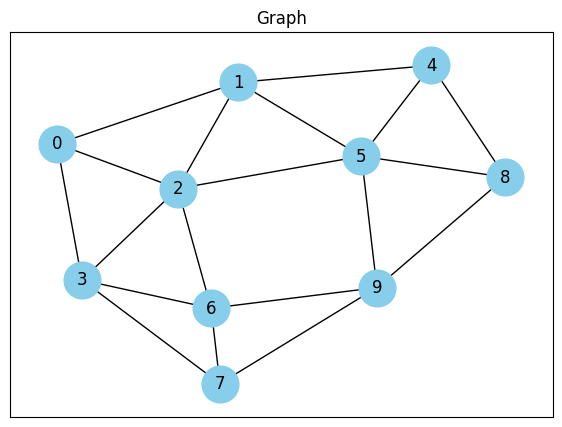


Sample Walks
[0, 3, 0, 2, 1, 0, 1, 5, 8, 5]
[0, 1, 0, 1, 4, 1, 0, 3, 6, 3]
[0, 3, 2, 6, 9, 5, 2, 1, 2, 6]
[0, 1, 0, 1, 5, 8, 9, 7, 6, 9]
[0, 2, 0, 1, 4, 8, 5, 1, 0, 3]
[0, 2, 6, 9, 8, 4, 1, 5, 2, 1]
[0, 3, 2, 6, 7, 6, 2, 5, 2, 3]
[0, 3, 7, 3, 0, 3, 0, 3, 7, 6]
[0, 1, 2, 6, 9, 5, 4, 5, 9, 6]
[0, 2, 0, 3, 6, 9, 6, 3, 0, 3]

Word2Vec Training Finished!

Node Embeddings

Node 0
[-0.047  0.376  0.224  0.232 -0.118 -0.015  0.717  0.052  0.143 -0.099
  0.307  0.45   0.295 -0.064 -0.511 -0.011]

Node 1
[-0.029  0.358  0.118  0.364 -0.194  0.017  0.735  0.036  0.115 -0.213
  0.233  0.413  0.205  0.    -0.47  -0.079]

Node 2
[-0.035  0.335  0.127  0.248 -0.106  0.051  0.778  0.051  0.131 -0.175
  0.252  0.438  0.201 -0.034 -0.506 -0.02 ]

Node 3
[-0.027  0.363  0.149  0.267 -0.146  0.026  0.766  0.091  0.059 -0.193
  0.263  0.426  0.301  0.    -0.441 -0.071]

Node 4
[-0.114  0.329  0.23   0.453 -0.135  0.06   0.683  0.076  0.1   -0.195
  0.348  0.258  0.259 -0.002 -0.517  0.027]

Node 5
[-0.085

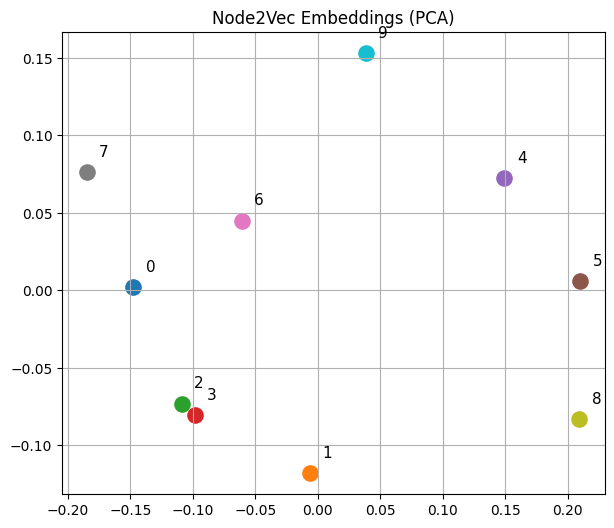

In [11]:

"""
=========================================================
Node2Vec From Scratch (Educational Implementation)
=========================================================

Pipeline
--------
1. Create graph (NetworkX)
2. Visualize graph
3. Compute Node2Vec transition probabilities
4. Perform biased random walks
5. Generate walk corpus
6. Train Word2Vec (Skip-Gram)
7. Learn node embeddings
8. Find similar nodes
9. Visualize embeddings with PCA

Author : Educational Version
"""

import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

# ------------------------------------------------------
# STEP 1 : Reproducibility
# ------------------------------------------------------
random.seed(42)
np.random.seed(42)

# ------------------------------------------------------
# STEP 2 : Create Graph
# ------------------------------------------------------
G = nx.Graph()

edges = [
    (0,1),(0,2),(0,3),
    (1,2),(1,4),(1,5),
    (2,3),(2,5),(2,6),
    (3,6),(3,7),
    (4,5),(4,8),
    (5,8),(5,9),
    (6,7),(6,9),
    (7,9),
    (8,9)
]

G.add_edges_from(edges)

print("="*60)
print("Graph Information")
print("="*60)
print("Nodes :", list(G.nodes()))
print("Edges :", list(G.edges()))

print("\nNeighbors")
for node in G.nodes():
    print(f"{node} -> {list(G.neighbors(node))}")

# ------------------------------------------------------
# STEP 3 : Visualize Graph
# ------------------------------------------------------
plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G,pos,node_color="skyblue",node_size=700)
plt.title("Graph")
plt.show()

# ------------------------------------------------------
# STEP 4 : Transition Probabilities
# ------------------------------------------------------
def transition_probabilities(graph, previous, current, p=1, q=1):
    """
    Compute Node2Vec transition probabilities.

    previous : previous node
    current  : current node
    """

    neighbors = list(graph.neighbors(current))
    weights = []

    for nbr in neighbors:

        # Return edge
        if nbr == previous:
            weight = 1/p

        # Neighbor connected to previous
        elif graph.has_edge(previous, nbr):
            weight = 1

        # Explore outward
        else:
            weight = 1/q

        weights.append(weight)

    weights = np.array(weights,dtype=float)
    probs = weights/weights.sum()

    return neighbors, probs


# ------------------------------------------------------
# STEP 5 : Node2Vec Walk
# ------------------------------------------------------
def node2vec_walk(graph,start,walk_length,p=1,q=1):

    walk=[start]

    # First move : uniform
    first_neighbors=list(graph.neighbors(start))

    if len(first_neighbors)==0:
        return walk

    first=random.choice(first_neighbors)
    walk.append(first)

    while len(walk)<walk_length:

        previous=walk[-2]
        current=walk[-1]

        neighbors,probs=transition_probabilities(
            graph,
            previous,
            current,
            p,
            q
        )

        next_node=random.choices(
            neighbors,
            weights=probs,
            k=1
        )[0]

        walk.append(next_node)

    return walk


# ------------------------------------------------------
# STEP 6 : Generate Walk Corpus
# ------------------------------------------------------
num_walks=10
walk_length=10
p=1
q=0.5          # Encourage exploration

walks=[]

for node in G.nodes():

    for _ in range(num_walks):

        walks.append(
            node2vec_walk(
                G,
                node,
                walk_length,
                p,
                q
            )
        )

print("\n"+"="*60)
print("Sample Walks")
print("="*60)

for w in walks[:10]:
    print(w)

# ------------------------------------------------------
# STEP 7 : Convert Walks to Sentences
# ------------------------------------------------------
sentences=[[str(v) for v in walk] for walk in walks]

# ------------------------------------------------------
# STEP 8 : Train Word2Vec
# ------------------------------------------------------
model=Word2Vec(
    sentences,
    vector_size=16,
    window=4,
    sg=1,
    epochs=100,
    workers=1,
    min_count=0
)

print("\nWord2Vec Training Finished!")

# ------------------------------------------------------
# STEP 9 : Print Embeddings
# ------------------------------------------------------
print("\n"+"="*60)
print("Node Embeddings")
print("="*60)

embeddings=[]

for node in G.nodes():

    emb=model.wv[str(node)]
    embeddings.append(emb)

    print(f"\nNode {node}")
    print(np.round(emb,3))

embeddings=np.array(embeddings)

# ------------------------------------------------------
# STEP 10 : Similar Nodes
# ------------------------------------------------------
print("\n"+"="*60)
print("Most Similar Nodes")
print("="*60)

for node in G.nodes():

    print(f"\nNode {node}")

    similar=model.wv.most_similar(str(node),topn=3)

    for n,s in similar:
        print(f"{n} : {s:.3f}")

# ------------------------------------------------------
# STEP 11 : PCA Visualization
# ------------------------------------------------------
pca=PCA(n_components=2)

points=pca.fit_transform(embeddings)

plt.figure(figsize=(7,6))

for i,node in enumerate(G.nodes()):

    plt.scatter(points[i,0],points[i,1],s=120)

    plt.text(
        points[i,0]+0.01,
        points[i,1]+0.01,
        str(node),
        fontsize=11
    )

plt.title("Node2Vec Embeddings (PCA)")
plt.grid(True)
plt.show()


**DEEPWALK**

                    DEEPWALK

                Graph (NetworkX/PyG)
                        │
                        ▼
             Build Adjacency List
                        │
                        ▼
        Start Random Walk from Every Node
                        │
                        ▼
         Uniform Random Walk (Equal Probability)
                        │
                        ▼
          Generate Multiple Walk Sequences
                        │
                        ▼
      Convert Walks into "Sentences"
                        │
                        ▼
       Train Word2Vec (Skip-Gram Model)
                        │
                        ▼
        Learn Low-Dimensional Embeddings
                        │
                        ▼
      Similarity Search / Classification /
      Clustering / Link Prediction / GNN

**NODE2VEC**

                   NODE2VEC

                Graph (NetworkX/PyG)
                        │
                        ▼
             Build Adjacency List
                        │
                        ▼
       Start Walk from Every Node
                        │
                        ▼
      Keep Track of Previous Node
                        │
                        ▼
      Compute Transition Probabilities
                using p and q
                        │
                        ▼
        Biased Random Walk
                        │
                        ▼
       Generate Multiple Walk Sequences
                        │
                        ▼
      Convert Walks into "Sentences"
                        │
                        ▼
      Train Word2Vec (Skip-Gram Model)
                        │
                        ▼
        Learn Low-Dimensional Embeddings
                        │
                        ▼
      Similarity Search / Classification /
      Clustering / Link Prediction / GNN

| Step                   | DeepWalk    | Node2Vec           |
| ---------------------- | ----------- | ------------------ |
| Graph Creation         | ✅           | ✅                  |
| Adjacency List         | ✅           | ✅                  |
| Random Walk            | Uniform     | Biased             |
| Previous Node Required | ❌           | ✅                  |
| Transition Probability | Equal       | Based on `p` & `q` |
| Walk Type              | First-order | Second-order       |
| Word2Vec               | Skip-Gram   | Skip-Gram          |
| Embeddings             | ✅           | ✅                  |
| Main Advantage         | Simple      | More expressive    |


## Cora Data (Planetoid)

Processing...
d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
d:\MACHINE LEARNING\GNN\GNN_Foundations\rag_llm\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')

DATASET INFORMATION
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

Number of Nodes       : 2708
Number of Edges       : 10556
Node Features         : 1433
Number of Classes     : 7

Feature Matrix Shape  : torch.Size([2708, 1433])
Edge Index Shape      : torch.Size([2, 10556])
Label Shape           : torch.Size([2708])


NETWORKX GRAPH
Graph with 2708 nodes and 5278 edges

Unique Nodes : 2708
Unique Edges : 5278


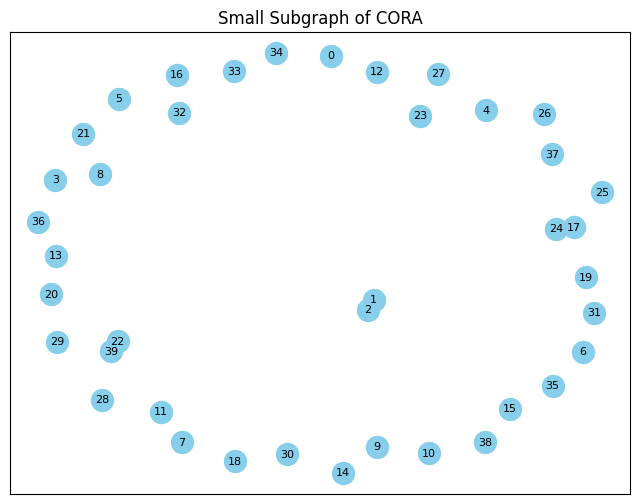



NODE2VEC RANDOM WALK
[0, 2582, 0, 1862, 926, 1862, 0, 1862, 1701, 1636, 24, 17, 927, 1316, 1301, 1542, 1607, 1221, 1577, 1054]


EXAMPLE TRANSITION
Previous Node : 0
Current Node  : 2582

Neighbors
0
1166
1862

Transition Probabilities
    0 ---> 0.2500
 1166 ---> 0.5000
 1862 ---> 0.2500


In [12]:
"""
=========================================================
Node2Vec From Scratch on CORA Dataset
=========================================================

PART 1

1. Import Libraries
2. Load Cora Dataset
3. Explore Dataset
4. Convert PyG Graph -> NetworkX
5. Visualize Graph
6. Transition Probability Function
7. Node2Vec Random Walk

Author : Educational Version
"""

# =====================================================
# STEP 1 : Import Libraries
# =====================================================

import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

# =====================================================
# STEP 2 : Fix Random Seeds
# =====================================================

random.seed(42)
np.random.seed(42)

# =====================================================
# STEP 3 : Load CORA Dataset
# =====================================================

dataset = Planetoid(
    root="data/Planetoid",
    name="Cora"
)

data = dataset[0]

# =====================================================
# STEP 4 : Explore Dataset
# =====================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(data)

print("\nNumber of Nodes       :", data.num_nodes)
print("Number of Edges       :", data.num_edges)
print("Node Features         :", data.num_node_features)
print("Number of Classes     :", dataset.num_classes)

print("\nFeature Matrix Shape  :", data.x.shape)
print("Edge Index Shape      :", data.edge_index.shape)
print("Label Shape           :", data.y.shape)

# =====================================================
# STEP 5 : Convert PyG -> NetworkX
# =====================================================

G = to_networkx(
    data,
    to_undirected=True
)

print("\n")
print("=" * 60)
print("NETWORKX GRAPH")
print("=" * 60)

print(G)

print("\nUnique Nodes :", G.number_of_nodes())
print("Unique Edges :", G.number_of_edges())

# =====================================================
# STEP 6 : Visualize a Small Portion of Graph
# =====================================================
#
# Entire CORA graph has 2708 nodes.
# Plotting everything becomes unreadable.
#
# We only visualize first 40 nodes.
#
# =====================================================

sample_nodes = list(range(40))

subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(8,6))

pos = nx.spring_layout(
    subgraph,
    seed=42
)

nx.draw_networkx(
    subgraph,
    pos,
    node_size=250,
    node_color="skyblue",
    with_labels=True,
    font_size=8
)

plt.title("Small Subgraph of CORA")

plt.show()

# =====================================================
# STEP 7 : Transition Probability Function
# =====================================================
#
# This is THE HEART of Node2Vec.
#
# Previous ---- Current ---- Next
#
# Three possibilities
#
# 1) Return Edge
#       weight = 1/p
#
# 2) Neighbor of Previous
#       weight = 1
#
# 3) Far Away Node
#       weight = 1/q
#
# =====================================================

def transition_probabilities(
    graph,
    previous,
    current,
    p=1.0,
    q=1.0
):
    """
    Compute transition probabilities for Node2Vec.

    Parameters
    ----------
    graph : NetworkX Graph

    previous : Previous node

    current : Current node

    p : Return parameter

    q : In-Out parameter

    Returns
    -------
    neighbors

    probabilities
    """

    # Get neighbors of current node
    neighbors = list(graph.neighbors(current))

    weights = []

    # -----------------------------------------
    # Calculate weight for every neighbor
    # -----------------------------------------

    for neighbor in neighbors:

        # -------------------------------
        # CASE 1
        #
        # Return to previous node
        # -------------------------------

        if neighbor == previous:

            weight = 1 / p

        # -------------------------------
        # CASE 2
        #
        # Neighbor connected to previous
        # -------------------------------

        elif graph.has_edge(previous, neighbor):

            weight = 1

        # -------------------------------
        # CASE 3
        #
        # Explore outward
        # -------------------------------

        else:

            weight = 1 / q

        weights.append(weight)

    # -----------------------------------------
    # Normalize weights
    # -----------------------------------------

    weights = np.array(
        weights,
        dtype=float
    )

    probabilities = weights / weights.sum()

    return neighbors, probabilities

# =====================================================
# STEP 8 : Node2Vec Random Walk
# =====================================================

def node2vec_walk(
    graph,
    start_node,
    walk_length,
    p=1,
    q=1
):
    """
    Perform one biased random walk.
    """

    walk = [start_node]

    # ------------------------------------
    # First step
    #
    # No previous node exists.
    #
    # Choose uniformly.
    # ------------------------------------

    first_neighbors = list(
        graph.neighbors(start_node)
    )

    if len(first_neighbors) == 0:

        return walk

    first_node = random.choice(
        first_neighbors
    )

    walk.append(first_node)

    # ------------------------------------
    # Remaining walk
    # ------------------------------------

    while len(walk) < walk_length:

        previous = walk[-2]

        current = walk[-1]

        neighbors, probabilities = transition_probabilities(

            graph,

            previous,

            current,

            p,

            q

        )

        if len(neighbors) == 0:

            break

        next_node = random.choices(

            neighbors,

            weights=probabilities,

            k=1

        )[0]

        walk.append(next_node)

    return walk

# =====================================================
# STEP 9 : Test One Walk
# =====================================================

print("\n")
print("=" * 60)
print("NODE2VEC RANDOM WALK")
print("=" * 60)

walk = node2vec_walk(

    graph=G,

    start_node=0,

    walk_length=20,

    p=1,

    q=0.5

)

print(walk)

# =====================================================
# STEP 10 : Explain One Transition
# =====================================================

print("\n")
print("=" * 60)
print("EXAMPLE TRANSITION")
print("=" * 60)

previous = walk[0]
current = walk[1]

neighbors, probabilities = transition_probabilities(

    G,

    previous,

    current,

    p=1,

    q=0.5

)

print("Previous Node :", previous)
print("Current Node  :", current)

print("\nNeighbors")

for n in neighbors:
    print(n)

print("\nTransition Probabilities")

for n, p in zip(neighbors, probabilities):

    print(f"{n:5d} ---> {p:.4f}")

In [13]:
# =====================================================
# STEP 11 : Generate Walk Corpus
# =====================================================
#
# Instead of generating one walk,
# Node2Vec generates multiple walks
# from every node.
#
# Example:
#
# Node 0
#   Walk 1
#   Walk 2
#   ...
#
# Node 1
#   Walk 1
#   Walk 2
#   ...
#
# =====================================================

NUM_WALKS = 10
WALK_LENGTH = 20

# Node2Vec Hyperparameters
P = 1.0
Q = 0.5

walks = []

print("\n")
print("=" * 60)
print("GENERATING NODE2VEC WALKS")
print("=" * 60)

# Generate walks from every node
for node in G.nodes():

    for _ in range(NUM_WALKS):

        walk = node2vec_walk(
            graph=G,
            start_node=node,
            walk_length=WALK_LENGTH,
            p=P,
            q=Q
        )

        walks.append(walk)

print("Total Walks Generated :", len(walks))

print("\nFirst 10 Walks\n")

for walk in walks[:10]:
    print(walk)


# =====================================================
# STEP 12 : Convert Walks into Sentences
# =====================================================
#
# Word2Vec expects strings instead of integers.
#
# Example
#
# [0,2,5,9]
#
# becomes
#
# ['0','2','5','9']
#
# =====================================================

sentences = []

for walk in walks:

    sentence = []

    for node in walk:

        sentence.append(str(node))

    sentences.append(sentence)

print("\n")
print("=" * 60)
print("FIRST 5 SENTENCES")
print("=" * 60)

for sentence in sentences[:5]:
    print(sentence)


# =====================================================
# STEP 13 : Train Word2Vec
# =====================================================
#
# Skip-Gram Model
#
# Same as DeepWalk.
#
# =====================================================

from gensim.models import Word2Vec

print("\n")
print("=" * 60)
print("TRAINING WORD2VEC")
print("=" * 60)

model = Word2Vec(

    sentences=sentences,

    vector_size=128,

    window=10,

    sg=1,

    min_count=0,

    workers=4,

    epochs=5

)

print("\nTraining Finished Successfully!")


# =====================================================
# STEP 14 : Build Embedding Matrix
# =====================================================
#
# Every node now has a
# 128-dimensional embedding.
#
# =====================================================

embeddings = []

for node in range(data.num_nodes):

    embedding = model.wv[str(node)]

    embeddings.append(embedding)

embeddings = np.array(embeddings)

print("\n")
print("=" * 60)
print("EMBEDDING MATRIX")
print("=" * 60)

print("Shape :", embeddings.shape)

# Expected:
#
# (2708,128)


# =====================================================
# STEP 15 : Print Sample Embeddings
# =====================================================

print("\n")
print("=" * 60)
print("FIRST FIVE NODE EMBEDDINGS")
print("=" * 60)

for node in range(5):

    print(f"\nNode {node}")

    print(np.round(embeddings[node], 3))


# =====================================================
# STEP 16 : Similar Nodes
# =====================================================

print("\n")
print("=" * 60)
print("MOST SIMILAR NODES")
print("=" * 60)

query_node = "0"

similar_nodes = model.wv.most_similar(
    query_node,
    topn=10
)

print(f"\nMost Similar Nodes to {query_node}\n")

for node, similarity in similar_nodes:

    print(f"Node {node:>5}   Similarity = {similarity:.4f}")



GENERATING NODE2VEC WALKS
Total Walks Generated : 27080

First 10 Walks

[0, 633, 1866, 633, 0, 1862, 926, 1862, 0, 633, 1701, 729, 1159, 729, 1221, 981, 1221, 729, 1159, 981]
[0, 1862, 1701, 1855, 1171, 681, 1445, 681, 1171, 510, 1013, 1840, 1377, 2069, 702, 822, 1973, 1525, 1914, 604]
[0, 2582, 0, 633, 1701, 1872, 1701, 343, 311, 1865, 311, 1132, 311, 690, 311, 1865, 1147, 2367, 894, 1845]
[0, 2582, 1166, 1986, 519, 836, 1013, 1729, 1625, 1309, 490, 2105, 517, 952, 517, 952, 2546, 628, 1725, 59]
[0, 1862, 1701, 1212, 1701, 1453, 1986, 1989, 460, 2532, 460, 1989, 460, 1989, 460, 1986, 1992, 1986, 2008, 2301]
[0, 2582, 1862, 2582, 1166, 1986, 1873, 603, 1821, 603, 1873, 1701, 13, 1701, 24, 2141, 2142, 2141, 1636, 24]
[0, 2582, 1862, 0, 633, 0, 2582, 1862, 0, 633, 1701, 532, 1863, 532, 1701, 1337, 2045, 236, 153, 2045]
[0, 2582, 1166, 2582, 1166, 1986, 151, 1986, 1812, 2034, 14, 2077, 14, 158, 14, 2075, 2076, 180, 791, 2034]
[0, 2582, 1862, 1701, 1212, 1701, 1863, 532, 1701, 1052, 170



NODE CLASSIFICATION
Training Samples : 140
Testing Samples  : 1000

Classification Accuracy : 0.6770


PCA VISUALIZATION


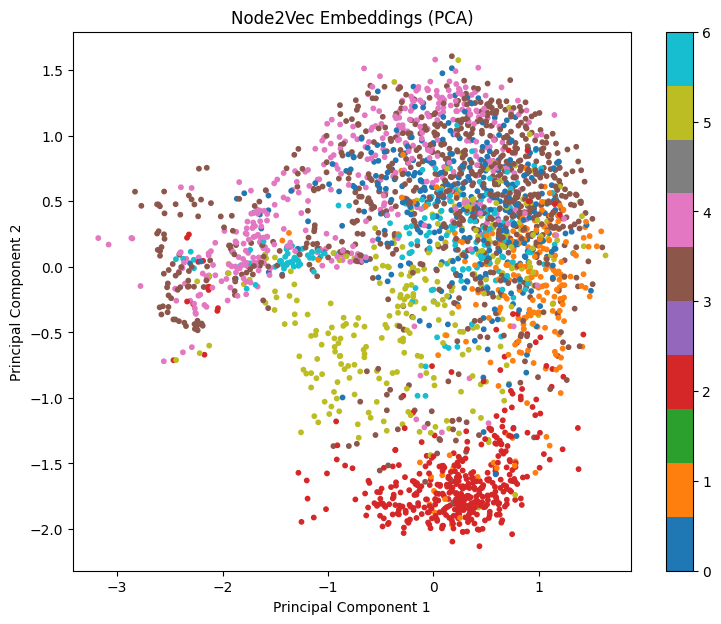



t-SNE VISUALIZATION


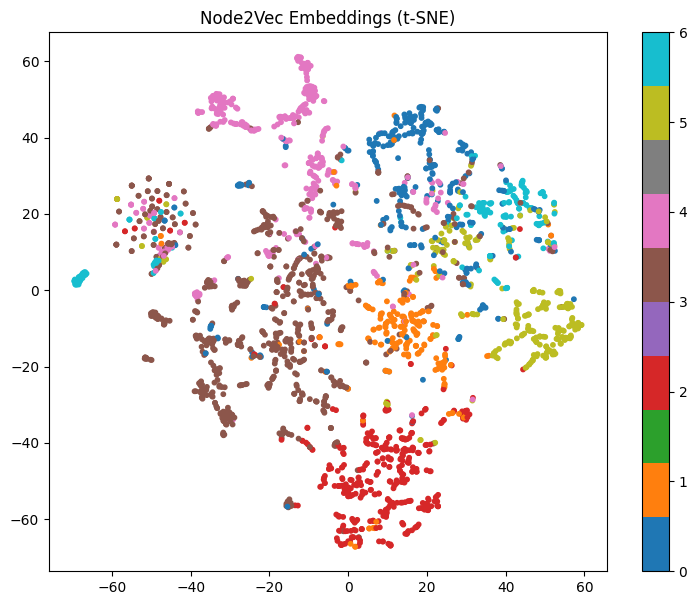



NODE2VEC HYPERPARAMETERS
Return Parameter (p) : 1.0
In-Out Parameter (q) : 0.5

Interpretation
- p = 1    : Neutral return behavior.
- Small q  : Encourages exploring farther nodes (DFS-like).


NODE2VEC PIPELINE COMPLETED

1. Loaded CORA Dataset

2. Converted PyTorch Geometric -> NetworkX

3. Implemented Node2Vec Transition Probabilities

4. Implemented Biased Random Walk

5. Generated Walk Corpus

6. Converted Walks into Sentences

7. Trained Word2Vec (Skip-Gram)

8. Learned Node Embeddings

9. Found Similar Nodes

10. Evaluated using Logistic Regression

11. Visualized Embeddings using PCA

12. Visualized Embeddings using t-SNE

Congratulations!
You have implemented Node2Vec completely from scratch.



In [14]:
# =====================================================
# STEP 17 : Node Classification
# =====================================================
#
# We evaluate the learned embeddings by training
# a simple Logistic Regression classifier.
#
# The Cora dataset already provides:
#
# train_mask
# test_mask
#
# We use embeddings as input features.
#
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("\n")
print("=" * 60)
print("NODE CLASSIFICATION")
print("=" * 60)

# Training embeddings
X_train = embeddings[data.train_mask.numpy()]

# Training labels
y_train = data.y[data.train_mask].numpy()

# Testing embeddings
X_test = embeddings[data.test_mask.numpy()]

# Testing labels
y_test = data.y[data.test_mask].numpy()

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# Logistic Regression Classifier
classifier = LogisticRegression(
    max_iter=5000,
    random_state=42
)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"\nClassification Accuracy : {accuracy:.4f}")


# =====================================================
# STEP 18 : PCA Visualization
# =====================================================
#
# PCA reduces
#
# 128 dimensions
#
# to
#
# 2 dimensions
#
# for visualization.
#
# =====================================================

from sklearn.decomposition import PCA

print("\n")
print("=" * 60)
print("PCA VISUALIZATION")
print("=" * 60)

pca = PCA(n_components=2)

pca_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    pca_embeddings[:,0],
    pca_embeddings[:,1],
    c=data.y.numpy(),
    cmap="tab10",
    s=10
)

plt.title("Node2Vec Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)

plt.show()


# =====================================================
# STEP 19 : t-SNE Visualization
# =====================================================
#
# t-SNE preserves local neighborhood
# much better than PCA.
#
# It is slower but produces
# more meaningful clusters.
#
# =====================================================

from sklearn.manifold import TSNE

print("\n")
print("=" * 60)
print("t-SNE VISUALIZATION")
print("=" * 60)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

tsne_embeddings = tsne.fit_transform(embeddings)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    tsne_embeddings[:,0],
    tsne_embeddings[:,1],
    c=data.y.numpy(),
    cmap="tab10",
    s=10
)

plt.title("Node2Vec Embeddings (t-SNE)")

plt.colorbar(scatter)

plt.show()


# =====================================================
# STEP 20 : Experiment with Different p and q
# =====================================================

print("\n")
print("=" * 60)
print("NODE2VEC HYPERPARAMETERS")
print("=" * 60)

print(f"Return Parameter (p) : {P}")
print(f"In-Out Parameter (q) : {Q}")

print("\nInterpretation")

if P < 1:
    print("- Small p  : Encourages returning to previous node.")
elif P > 1:
    print("- Large p  : Discourages returning.")
else:
    print("- p = 1    : Neutral return behavior.")

if Q < 1:
    print("- Small q  : Encourages exploring farther nodes (DFS-like).")
elif Q > 1:
    print("- Large q  : Encourages staying local (BFS-like).")
else:
    print("- q = 1    : Neutral exploration.")


# =====================================================
# STEP 21 : Complete Summary
# =====================================================

print("\n")
print("=" * 60)
print("NODE2VEC PIPELINE COMPLETED")
print("=" * 60)

print("""
1. Loaded CORA Dataset

2. Converted PyTorch Geometric -> NetworkX

3. Implemented Node2Vec Transition Probabilities

4. Implemented Biased Random Walk

5. Generated Walk Corpus

6. Converted Walks into Sentences

7. Trained Word2Vec (Skip-Gram)

8. Learned Node Embeddings

9. Found Similar Nodes

10. Evaluated using Logistic Regression

11. Visualized Embeddings using PCA

""")